# Loan Approval Prediction

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

# Scikit-Learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Imbalanced-Learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Plotting defaults
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Setup complete.')


Setup complete.


## 2. Data Loading & Initial Exploration

In [2]:
# Dataset loading from CSV
df = pd.read_csv('data/loan_data.csv')
print(f'Dataset shape: {df.shape}')
display(df.head())


Dataset shape: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
# Dataset shape, types, and missing value summary
display(df.info())
print('\nMissing values:\n')
display(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

None


Missing values:



person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Distribution plots and outlier checks for key numerical and categorical
features. The class balance of the target variable (`loan_status`) is
assessed to determine whether imbalance handling is needed.

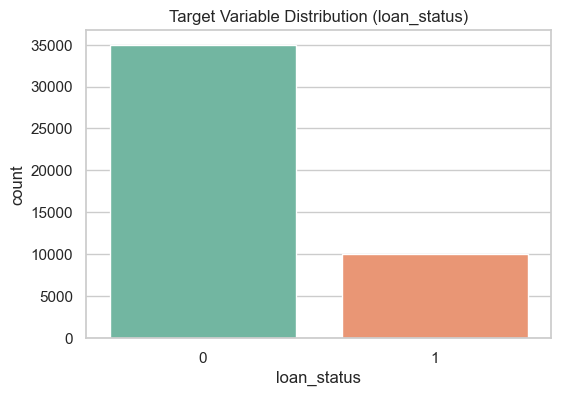

In [4]:
# Target variable class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette='Set2')
plt.title('Target Variable Distribution (loan_status)')
plt.show()


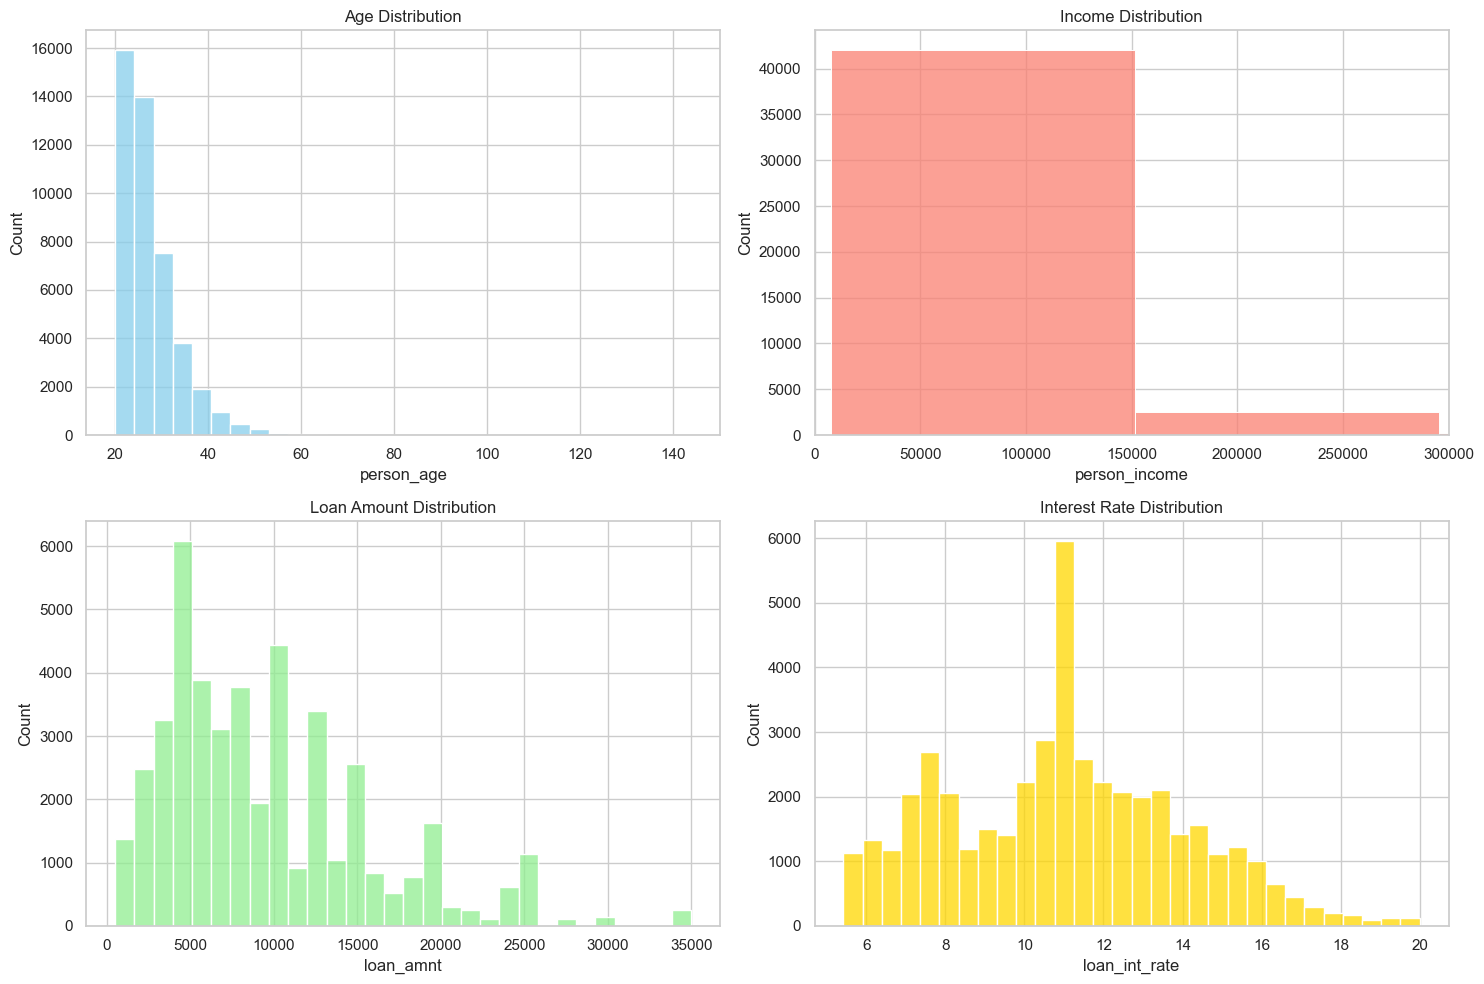

In [5]:
# Numerical feature distributions (age, income, loan amount, interest rate)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=df, x='person_age', bins=30, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution')

sns.histplot(data=df, x='person_income', bins=50, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Income Distribution')
axes[0, 1].set_xlim(0, 300000)

sns.histplot(data=df, x='loan_amnt', bins=30, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Loan Amount Distribution')

sns.histplot(data=df, x='loan_int_rate', bins=30, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Interest Rate Distribution')

plt.tight_layout()
plt.show()


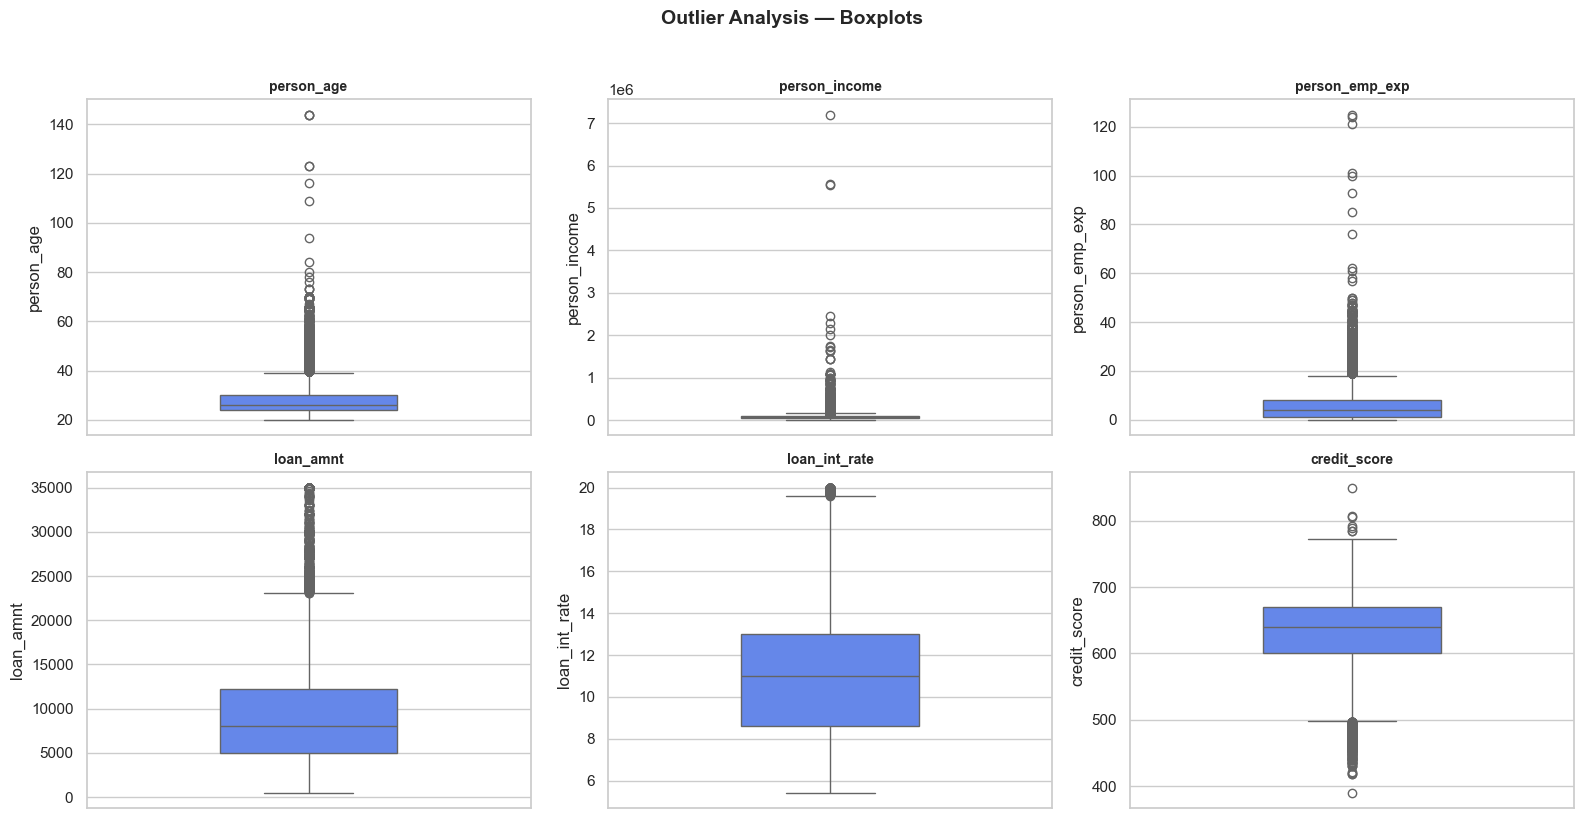

In [6]:
# Outlier analysis via boxplots for continuous features
outlier_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                'loan_int_rate', 'credit_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(outlier_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df, y=col, ax=ax, color='#4f7cff', width=0.4)
    ax.set_title(col, fontweight='bold', fontsize=10)

plt.suptitle('Outlier Analysis — Boxplots', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Data Preprocessing Pipeline
A `ColumnTransformer` with three sub-pipelines handles each feature type:
numerical features are imputed (median) and scaled (`StandardScaler`);
education is ordinal-encoded to preserve its hierarchy, while remaining categoricals
are one-hot encoded. The entire transform is encapsulated in a pipeline to
prevent data leakage during cross-validation.

In [7]:
# Feature-target separation
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Feature categorization by data type
numerical_features = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

ordinal_features = ['person_education']
education_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

nominal_features = ['person_gender', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

# Sub-pipelines: imputation + transformation per feature type
num_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

ord_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1))
])

nom_pipe = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combined preprocessor for all feature types
preprocessor = ColumnTransformer([
    ('num', num_pipe, numerical_features),
    ('ord', ord_pipe, ordinal_features),
    ('nom', nom_pipe, nominal_features)
])

print('Preprocessor defined.')


Preprocessor defined.


## 5. Train-Test Split
80/20 stratified split to preserve the class distribution across both sets.

In [8]:
# 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')


Train: (36000, 13)  |  Test: (9000, 13)


## 6. Baseline Model (Logistic Regression)
Logistic Regression serves as the baseline due to its simplicity and
interpretability. SMOTE is applied within the `imblearn` pipeline so that
synthetic oversampling only affects the training folds.

In [9]:
# Model evaluation function (prints all key metrics + classification report)
def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f'--- {name} ---')
    print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'  F1-Score:  {f1_score(y_true, y_pred):.4f}')
    if y_prob is not None:
        print(f'  ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}')
    print('\n' + classification_report(y_true, y_pred, target_names=['Rejected', 'Approved']))
    print('-' * 40 + '\n')


In [10]:
# Impact of SMOTE: Logistic Regression with vs without oversampling
# This comparison demonstrates the effect of class imbalance handling.

# Without SMOTE
pipe_no_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_no_smote.fit(X_train, y_train)
y_pred_ns = pipe_no_smote.predict(X_test)
y_prob_ns = pipe_no_smote.predict_proba(X_test)[:, 1]
evaluate_model('Logistic Regression (without SMOTE)', y_test, y_pred_ns, y_prob_ns)

# With SMOTE
pipe_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_smote.fit(X_train, y_train)
y_pred_s = pipe_smote.predict(X_test)
y_prob_s = pipe_smote.predict_proba(X_test)[:, 1]
evaluate_model('Logistic Regression (with SMOTE)', y_test, y_pred_s, y_prob_s)


--- Logistic Regression (without SMOTE) ---
  Accuracy:  0.8994
  Precision: 0.7892
  Recall:    0.7470
  F1-Score:  0.7675
  ROC-AUC:   0.9562

              precision    recall  f1-score   support

    Rejected       0.93      0.94      0.94      7000
    Approved       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000

----------------------------------------



--- Logistic Regression (with SMOTE) ---
  Accuracy:  0.8622
  Precision: 0.6318
  Recall:    0.9110
  F1-Score:  0.7461
  ROC-AUC:   0.9562

              precision    recall  f1-score   support

    Rejected       0.97      0.85      0.91      7000
    Approved       0.63      0.91      0.75      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.83      9000
weighted avg       0.90      0.86      0.87      9000

----------------------------------------



## 7. Comparative Modeling
All five classifiers listed in the proposal are trained: Logistic Regression
(baseline), Decision Tree, Random Forest, SVM, and KNN. Each is wrapped in an
`imblearn` pipeline with SMOTE applied to training data only.

In [11]:
# Classifier definitions
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(),
}

results = {}

for name, clf in classifiers.items():
    print(f'Training {name}...')
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', clf)
    ])

    # Training, prediction, and evaluation
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    evaluate_model(name, y_test, y_pred, y_prob)
    results[name] = pipeline

print('All models trained and evaluated.')


Training Logistic Regression...
--- Logistic Regression ---
  Accuracy:  0.8622
  Precision: 0.6318
  Recall:    0.9110
  F1-Score:  0.7461
  ROC-AUC:   0.9562

              precision    recall  f1-score   support

    Rejected       0.97      0.85      0.91      7000
    Approved       0.63      0.91      0.75      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.83      9000
weighted avg       0.90      0.86      0.87      9000

----------------------------------------

Training Decision Tree...
--- Decision Tree ---
  Accuracy:  0.8892
  Precision: 0.7250
  Recall:    0.8080
  F1-Score:  0.7642
  ROC-AUC:   0.8602

              precision    recall  f1-score   support

    Rejected       0.94      0.91      0.93      7000
    Approved       0.72      0.81      0.76      2000

    accuracy                           0.89      9000
   macro avg       0.83      0.86      0.85      9000
weighted avg       0.89      0.89      0.89      

## 8. Hyperparameter Tuning
Grid search with Stratified 5-Fold CV is applied to Random Forest and SVM,
as specified in the proposal. ROC-AUC is the scoring metric, chosen because
accuracy alone can be misleading under class imbalance (Lessmann et al., 2015).

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest tuning
rf_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
}

rf_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

print('Tuning Random Forest...')
rf_grid = GridSearchCV(rf_pipe, rf_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV ROC-AUC: {rf_grid.best_score_:.4f} ± {rf_grid.cv_results_["std_test_score"][rf_grid.best_index_]:.4f}')

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]
evaluate_model('Random Forest (Tuned)', y_test, y_pred_rf, y_prob_rf)


Tuning Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV ROC-AUC: 0.9723 ± 0.0016
--- Random Forest (Tuned) ---
  Accuracy:  0.9218
  Precision: 0.8176
  Recall:    0.8340
  F1-Score:  0.8257
  ROC-AUC:   0.9736

              precision    recall  f1-score   support

    Rejected       0.95      0.95      0.95      7000
    Approved       0.82      0.83      0.83      2000

    accuracy                           0.92      9000
   macro avg       0.88      0.89      0.89      9000
weighted avg       0.92      0.92      0.92      9000

----------------------------------------



In [13]:
# SVM tuning (C and kernel, as specified in proposal)
svm_params = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf', 'linear'],
}

svm_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(probability=True, random_state=42))
])

print('Tuning SVM...')
svm_grid = GridSearchCV(svm_pipe, svm_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train)

print(f'Best params: {svm_grid.best_params_}')
print(f'Best CV ROC-AUC: {svm_grid.best_score_:.4f} ± {svm_grid.cv_results_["std_test_score"][svm_grid.best_index_]:.4f}')

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]
evaluate_model('SVM (Tuned)', y_test, y_pred_svm, y_prob_svm)


Tuning SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: {'classifier__C': 1, 'classifier__kernel': 'rbf'}
Best CV ROC-AUC: 0.9601 ± 0.0027
--- SVM (Tuned) ---
  Accuracy:  0.8824
  Precision: 0.6728
  Recall:    0.9170
  F1-Score:  0.7761
  ROC-AUC:   0.9616

              precision    recall  f1-score   support

    Rejected       0.97      0.87      0.92      7000
    Approved       0.67      0.92      0.78      2000

    accuracy                           0.88      9000
   macro avg       0.82      0.89      0.85      9000
weighted avg       0.91      0.88      0.89      9000

----------------------------------------



## 9. Model Export
The best-performing pipeline is serialized to disk. Since the pipeline
encapsulates imputation, scaling, encoding, and the classifier, it can be
loaded directly by the Flask backend without re-implementing the
transformation logic.

In [14]:
# Best model serialization to disk
export_path = 'best_model_pipeline.pkl'
joblib.dump(best_rf, export_path)
print(f'Model saved to {export_path}')

# Verification: reload and single-sample prediction
loaded_model = joblib.load(export_path)
sample = X_test.iloc[[0]]
print('\nSample input:')
display(sample)

pred = loaded_model.predict(sample)
prob = loaded_model.predict_proba(sample)[:, 1]
print(f"\nPrediction: {'Approved' if pred[0] == 1 else 'Rejected'}  (Prob: {prob[0]:.4f})")


Model saved to best_model_pipeline.pkl

Sample input:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
10750,25.0,female,Bachelor,84973.0,2,MORTGAGE,14000.0,VENTURE,5.42,0.16,3.0,634,No



Prediction: Rejected  (Prob: 0.0150)
